##  1. Выделение ROI (Region of Interest)
Анализ исходных кадров выявил проблему: в поле зрения камеры попадает соседний бункер (№13). Если подать полный кадр в нейросеть, она будет реагировать на уровень сырья в соседнем бункерe. Для решения этой проблемы мы применяем жесткий кроп (отсекаем ~55% кадра справа), оставляя только целевой бункер №15.

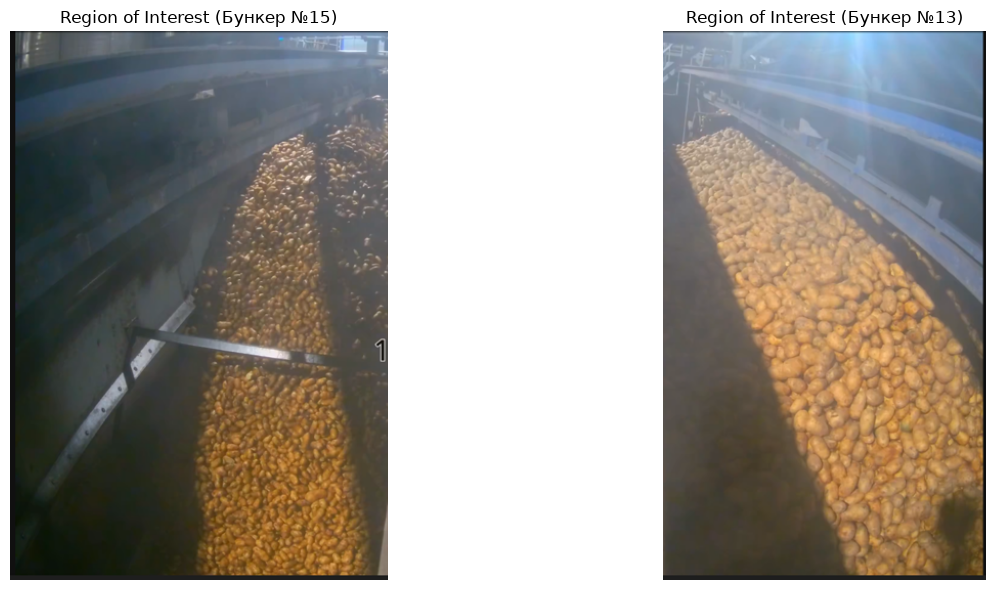

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt # <-- Добавлен недостающий импорт
from pathlib import Path

def load_and_crop_roi(image_path: str | Path, roi_start: float = 0.0, roi_end: float = 1.0) -> np.ndarray:
    """
    Загружает изображение и вырезает строго заданную область по ширине (убирая мертвые зоны).
    
    :param image_path: Путь к изображению.
    :param roi_start: Начало среза по оси X (доля от ширины, от 0.0 до 1.0).
    :param roi_end: Конец среза по оси X (доля от ширины, от 0.0 до 1.0).
    """
    img = cv2.imread(str(image_path))
    if img is None:
        raise FileNotFoundError(f"Не найдено изображение: {image_path}")
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    h, w = img_rgb.shape[:2]
    x_start = int(w * roi_start)
    x_end = int(w * roi_end)
    
    return img_rgb[:, x_start:x_end]

# --- Использование ---
# Задаем путь к тестовому изображению
sample_img = "../data/raw/50.png" 

# Левый бункер (№15) - от 0% до 48% ширины
roi_left = load_and_crop_roi(sample_img, roi_start=0.0, roi_end=0.48)

# Правый бункер (№13) - пропускаем балку, начинаем с 59% до 100%
roi_right = load_and_crop_roi(sample_img, roi_start=0.59, roi_end=1.0)
    
# --- Демонстрация ---
# Выводим обе нарезки рядом для наглядного сравнения
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Отрисовка левого бункера
axes[0].imshow(roi_left)
axes[0].set_title("Region of Interest (Бункер №15)")
axes[0].axis('off')

# Отрисовка правого бункера
axes[1].imshow(roi_right)
axes[1].set_title("Region of Interest (Бункер №13)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 2. Pixel-based baseline (Алгоритм без ML)
Прежде чем применять Deep Learning, необходимо понять физику процесса. Мы используем цветовую сегментацию (HSV), чтобы посчитать площадь, занимаемую картофелем.

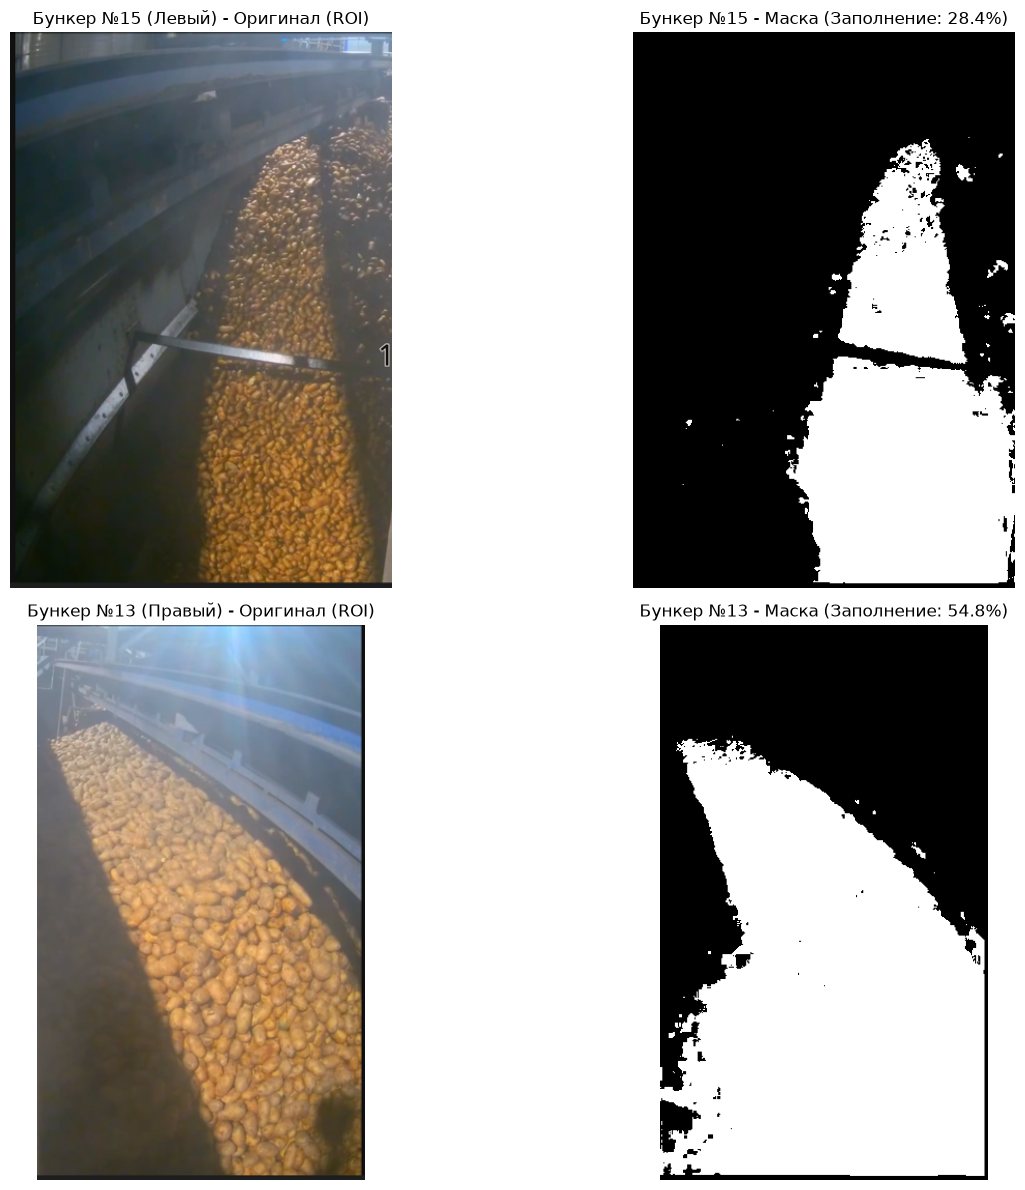

In [12]:
def estimate_fill_baseline_hsv(roi_img: np.ndarray):
    """
    Оценивает процент заполнения бункера на основе цветовой маски (HSV).
    Это наш Baseline (нулевая линия) для сравнения с нейросетью.
    """
    # Переводим в HSV (Hue, Saturation, Value) — лучше работает при разном освещении
    hsv = cv2.cvtColor(roi_img, cv2.COLOR_RGB2HSV)
    
    # Задаем диапазон цвета картофеля (подбирается эмпирически)
    # Желто-коричневые оттенки
    lower_potato = np.array([10, 50, 50])
    upper_potato = np.array([40, 255, 255])
    
    # Создаем бинарную маску: 255 там где картошка, 0 где фон
    mask = cv2.inRange(hsv, lower_potato, upper_potato)
    
    # Считаем процент
    potato_pixels = cv2.countNonZero(mask)
    total_pixels = mask.shape[0] * mask.shape[1]
    
    fill_percentage = (potato_pixels / total_pixels) * 100
    
    return fill_percentage, mask

# --- Использование ---
sample_img = "../data/raw/50.png" 

# 1. Левый бункер (№15) - берем от 0% до 48% ширины кадра
roi_img_left = load_and_crop_roi(sample_img, roi_start=0.0, roi_end=0.48)
fill_pct_left, mask_left = estimate_fill_baseline_hsv(roi_img_left)

# 2. Правый бункер (№13) - пропускаем балку, берем от 59% до 100% ширины кадра
roi_img_right = load_and_crop_roi(sample_img, roi_start=0.59, roi_end=1.0)
fill_pct_right, mask_right = estimate_fill_baseline_hsv(roi_img_right)

# --- Визуализация результатов для обоих бункеров ---
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Левый бункер (№15)
axes[0, 0].imshow(roi_img_left)
axes[0, 0].set_title("Бункер №15 (Левый) - Оригинал (ROI)")
axes[0, 0].axis('off')

axes[0, 1].imshow(mask_left, cmap='gray')
axes[0, 1].set_title(f"Бункер №15 - Маска (Заполнение: {fill_pct_left:.1f}%)")
axes[0, 1].axis('off')

# Правый бункер (№13)
axes[1, 0].imshow(roi_img_right)
axes[1, 0].set_title("Бункер №13 (Правый) - Оригинал (ROI)")
axes[1, 0].axis('off')

axes[1, 1].imshow(mask_right, cmap='gray')
axes[1, 1].set_title(f"Бункер №13 - Маска (Заполнение: {fill_pct_right:.1f}%)")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

## 3. Генерация синтетики (Albumentations)
Для запуска пилота в условиях экстремального дефицита данных (5 фото), мы применяем библиотеку Albumentations. Пайплайн имитирует реальные заводские условия: пыль на объективе (GaussNoise), вибрации (MotionBlur), перепады освещения (RandomBrightnessContrast) и артефакты сжатия RTSP-потока.

/tmp/ipykernel_23696/3709468420.py:7: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(20.0, 60.0), p=0.5), # Пыль на объективе
/tmp/ipykernel_23696/3709468420.py:9: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=50, quality_upper=80, p=0.7) # Артефакты RTSP


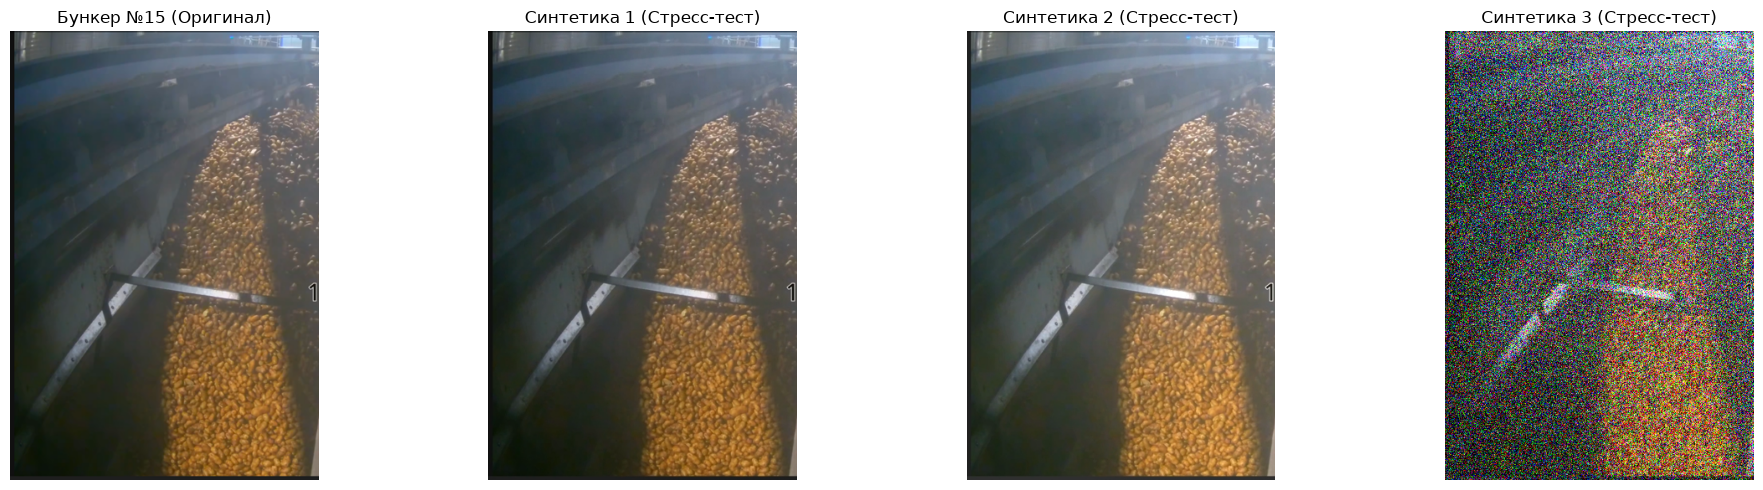

In [7]:
import albumentations as A
import matplotlib.pyplot as plt

# Пайплайн аугментаций, имитирующий суровые заводские условия
factory_transform = A.Compose([
    A.RandomBrightnessContrast(brightness_limit=0.4, contrast_limit=0.4, p=0.8), # Блики и тени
    A.GaussNoise(var_limit=(20.0, 60.0), p=0.5), # Пыль на объективе
    A.MotionBlur(blur_limit=7, p=0.3), # Вибрация конвейера
    A.ImageCompression(quality_lower=50, quality_upper=80, p=0.7) # Артефакты RTSP
])

# Используем именно левый бункер (roi_left)
# Убедись, что roi_left был определен ранее через load_and_crop_roi(..., roi_start=0.0, roi_end=0.48)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# 1. Оригинал
axes[0].imshow(roi_left)
axes[0].set_title("Бункер №15 (Оригинал)")
axes[0].axis('off')

# 2. Генерируем 3 варианта синтетики
for i in range(1, 4):
    augmented = factory_transform(image=roi_left)['image']
    axes[i].imshow(augmented)
    axes[i].set_title(f"Синтетика {i} (Стресс-тест)")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## 4. Калибровка Baseline

In [13]:
from pathlib import Path

# 1. Определяем пути к данным (исправляем NameError)
data_dir = Path("../data/raw")
image_paths = sorted(data_dir.glob("*.png"), key=lambda x: int(x.stem))

print("Калибровка Pixel-based Baseline (только Левый бункер №15):")
print("-" * 50)
calibration_map = {}

for path in image_paths:
    # 2. Используем правильные аргументы roi_start и roi_end (исправляем TypeError)
    roi_left = load_and_crop_roi(path, roi_start=0.0, roi_end=0.48)
    
    # Считаем процент пикселей именно для этой чистой области
    fill_pct, _ = estimate_fill_baseline_hsv(roi_left)
    real_class = path.stem
    calibration_map[real_class] = fill_pct
    
    print(f"Реальный уровень: {real_class:>3}% | Заполнение (HSV): {fill_pct:>6.2f}%")

print("-" * 50)

Калибровка Pixel-based Baseline (только Левый бункер №15):
--------------------------------------------------
Реальный уровень:   0% | Заполнение (HSV):   0.03%
Реальный уровень:  25% | Заполнение (HSV):  24.36%
Реальный уровень:  50% | Заполнение (HSV):  28.44%
Реальный уровень:  75% | Заполнение (HSV):  49.40%
Реальный уровень: 100% | Заполнение (HSV):  50.88%
--------------------------------------------------


## 5. Генерация датасета для YOLO

In [14]:
import os
import cv2
import albumentations as A
from pathlib import Path
from tqdm import tqdm # Для красивого прогресс-бара

# Настраиваем жесткие аугментации
factory_transform = A.Compose([
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.8),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.5),
    A.MotionBlur(blur_limit=5, p=0.3),
    A.ImageCompression(quality_lower=50, quality_upper=90, p=0.5),
    A.HorizontalFlip(p=0.5) # Немного разнообразим геометрию
])

def create_synthetic_dataset(raw_dir: str, out_dir: str, copies_per_image: int = 100):
    raw_path = Path(raw_dir)
    out_path = Path(out_dir)
    
    # Создаем структуру папок для YOLO (train/0, train/25, ...)
    for class_name in ['0', '25', '50', '75', '100']:
        (out_path / 'train' / class_name).mkdir(parents=True, exist_ok=True)
        (out_path / 'val' / class_name).mkdir(parents=True, exist_ok=True) # Валидация
        
    image_paths = list(raw_path.glob("*.png"))
    
    print(f"Генерация синтетического датасета ({copies_per_image} копий на класс)...")
    
    for img_path in tqdm(image_paths):
        class_name = img_path.stem # '0', '25', '50' и т.д.
        
        # 1. Загружаем и отрезаем лишний бункер (наш ROI)
        roi_img = load_and_crop_roi(img_path)
        
        # 2. Генерируем Train (80% данных)
        train_copies = int(copies_per_image * 0.8)
        for i in range(train_copies):
            aug = factory_transform(image=roi_img)['image']
            # Переводим обратно в BGR для сохранения через cv2
            save_path = out_path / 'train' / class_name / f"{class_name}_aug_{i}.jpg"
            cv2.imwrite(str(save_path), cv2.cvtColor(aug, cv2.COLOR_RGB2BGR))
            
        # 3. Генерируем Val (20% данных)
        val_copies = copies_per_image - train_copies
        for i in range(val_copies):
            aug = factory_transform(image=roi_img)['image']
            save_path = out_path / 'val' / class_name / f"{class_name}_val_{i}.jpg"
            cv2.imwrite(str(save_path), cv2.cvtColor(aug, cv2.COLOR_RGB2BGR))

# Запускаем генерацию (создаст 500 картинок в папке data/synthetic_dataset)
create_synthetic_dataset("../data/raw", "../data/synthetic_dataset", copies_per_image=100)
print("Датасет готов!")

/tmp/ipykernel_23696/3716546696.py:10: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.5),
/tmp/ipykernel_23696/3716546696.py:12: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=50, quality_upper=90, p=0.5),


Генерация синтетического датасета (100 копий на класс)...


100%|██████████| 5/5 [00:04<00:00,  1.06it/s]

Датасет готов!


## 6. Обучение YOLOv11-cls

In [15]:
from ultralytics import YOLO

# Загружаем предобученную на ImageNet легкую модель YOLOv8 (nano)
# Библиотека сама скачает yolov8n-cls.pt (около 5 МБ)
model = YOLO('yolov8n-cls.pt')

print("Начинаем обучение модели...")

results = model.train(
    data='../data/synthetic_dataset',
    epochs=10,
    imgsz=224,
    device='cpu', 
    project='../models',
    name='bunker_poc'
)

Начинаем обучение модели...
Ultralytics 8.4.82 🚀 Python-3.12.3 torch-2.12.1+cu130 CPU (AMD Ryzen 9 PRO 8945HS w/ Radeon 780M Graphics)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/synthetic_dataset, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=bunker_poc, nbs=64, nms=False, opset=None, opt

## 7. Инференс (Проверка результата)

📂 Загружаем веса из: /home/tesni/projects/BunkerVision/runs/models/bunker_poc/weights/best.pt

🤖 Результат работы ML-модели:
----------------------------------------
Предсказанный уровень: 75%
Уверенность модели:    99.9%
----------------------------------------


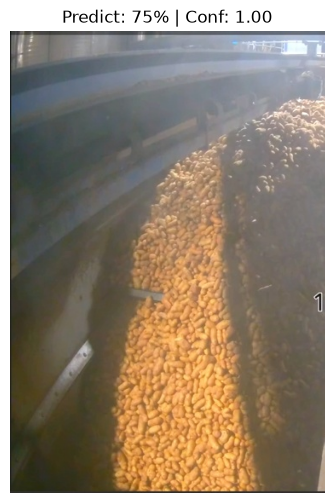

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. Динамический поиск весов
# Базовый путь (относительно папки notebooks/)
base_weights_dir = "../runs/models/bunker_poc/weights/"
weights_path = os.path.join(base_weights_dir, "best.pt")

# Страховка: если best.pt не создался (бывает, если метрики не улучшались на валидации), берем last.pt
if not os.path.exists(weights_path):
    weights_path = os.path.join(base_weights_dir, "last.pt")
    print(f"⚠️ best.pt не найден, загружаем last.pt")

print(f"📂 Загружаем веса из: {os.path.abspath(weights_path)}")
best_model = YOLO(weights_path)

# 2. Путь к тестовой картинке
test_image = "../data/synthetic_dataset/val/75/75_val_0.jpg"
# test_image = "../data/synthetic_dataset/val/50/50_val_0.jpg" # или 25
# test_image = "../data/synthetic_dataset/val/25/25_val_0.jpg" 
# test_image = "../data/raw/25.png"



if not os.path.exists(test_image):
    print(f"❌ Ошибка: Картинка не найдена по пути {os.path.abspath(test_image)}")
    print("Проверь структуру папок в ../data/synthetic_dataset/val/")
else:
    # 3. Делаем предикт
    prediction = best_model(test_image, verbose=False)[0]

    # Извлекаем результаты
    top1_index = prediction.probs.top1
    confidence = prediction.probs.top1conf.item()
    predicted_class = prediction.names[top1_index]

    print("\n🤖 Результат работы ML-модели:")
    print("-" * 40)
    print(f"Предсказанный уровень: {predicted_class}%")
    print(f"Уверенность модели:    {confidence * 100:.1f}%")
    print("-" * 40)

    # 4. Визуализация
    img_to_show = cv2.cvtColor(cv2.imread(test_image), cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(6, 6))
    plt.imshow(img_to_show)
    plt.title(f"Predict: {predicted_class}% | Conf: {confidence:.2f}")
    plt.axis('off')
    plt.show()

Обучение модели YOLOv8n-cls на синтетическом датасете (сгенерированном из 5 эталонных фото методом аугментации) показало сходимость пайплайна (Accuracy 100% на синтетическом val-наборе). Однако данная метрика является Proof of Concept архитектуры, а не оценкой реальной точности. Валидационная выборка состоит из тех же базовых изображений, что и тренировочная, только с примененными шумами. Для выхода в пилот (Этап 1) критически необходим сбор реального датасета (Shadow Mode) в условиях цеха для оценки реального mAP и калибровки порогов уверенности (confidence thresholds)